# 04. A/B Test Design & Simulation

이 노트북은 앞선 퍼널 분석과 상품/카테고리 분석 결과를 바탕으로
이커머스 전환율 개선을 위한 A/B Test를 설계하고 시뮬레이션한다.

이 데이터셋에는 실제 A/B Test group 컬럼이 없다.
따라서 이 노트북의 목적은 “이미 수행된 실험 결과 분석”이 아니라,
현재 행동 로그에서 확인한 baseline conversion rate를 기준으로
실무형 A/B Test를 어떻게 설계할 수 있는지 보여주는 것이다.

핵심 질문은 다음과 같다.

- 어떤 전환 지표를 primary metric으로 삼을 것인가?
- 현재 baseline conversion rate는 얼마인가?
- 목표 uplift별로 필요한 표본 수는 얼마인가?
- 가상의 실험 결과에서 통계적으로 유의한 차이를 어떻게 판단하는가?
- 실험 결과가 비즈니스 impact로는 어떻게 해석되는가?
- 어떤 카테고리/상품군을 실험 대상으로 우선 선정할 수 있는가?

In [1]:
# ============================================================
# 0. Library Setting
# ============================================================

from pathlib import Path
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest,
    confint_proportions_2indep,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.2.3
numpy: 2.1.3


In [2]:
# ============================================================
# 1. Project Path Setting
# ============================================================

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [PROCESSED_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EVENTS_PARQUET_PATH = PROCESSED_DIR / "events_clean.parquet"
EVENTS_CSV_PATH = PROCESSED_DIR / "events_clean.csv"

CATEGORY_PERFORMANCE_PARQUET_PATH = PROCESSED_DIR / "category_performance.parquet"
ITEM_PERFORMANCE_PARQUET_PATH = PROCESSED_DIR / "item_performance.parquet"

BASELINE_METRIC_TABLE_PATH = TABLE_DIR / "02_ab_test_baseline_metric_table.csv"
OPTIMIZATION_CATEGORIES_PATH = TABLE_DIR / "03_abtest_optimization_candidate_categories.csv"
EXPANSION_CATEGORIES_PATH = TABLE_DIR / "03_abtest_expansion_candidate_categories.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("events parquet exists:", EVENTS_PARQUET_PATH.exists())
print("events csv exists:", EVENTS_CSV_PATH.exists())
print("category performance exists:", CATEGORY_PERFORMANCE_PARQUET_PATH.exists())
print("item performance exists:", ITEM_PERFORMANCE_PARQUET_PATH.exists())

PROJECT_ROOT: c:\Users\USER\Desktop\ecommerce_ab_test_project
events parquet exists: False
events csv exists: True
category performance exists: False
item performance exists: False


In [3]:
# ============================================================
# 2. Utility Functions
# ============================================================

def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    save_path = TABLE_DIR / filename
    df.to_csv(save_path, index=index, encoding="utf-8-sig")
    print(f"saved: {save_path}")
    return save_path


def save_chart(filename: str) -> Path:
    save_path = CHART_DIR / filename
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"saved: {save_path}")
    return save_path


def read_processed_data(parquet_path: Path, csv_path: Path | None = None, name: str = "data") -> pd.DataFrame:
    if parquet_path.exists():
        print(f"loading {name} from parquet:", parquet_path)
        return pd.read_parquet(parquet_path)

    if csv_path is not None and csv_path.exists():
        print(f"loading {name} from csv:", csv_path)
        return pd.read_csv(csv_path)

    raise FileNotFoundError(f"{name} 파일을 찾을 수 없습니다.")


def safe_divide(numerator, denominator):
    return np.where(denominator > 0, numerator / denominator, np.nan)


def two_proportion_test(control_success, control_total, treatment_success, treatment_total):
    count = np.array([control_success, treatment_success])
    nobs = np.array([control_total, treatment_total])

    z_stat, p_value = proportions_ztest(count=count, nobs=nobs, alternative="two-sided")

    control_rate = control_success / control_total
    treatment_rate = treatment_success / treatment_total
    absolute_lift = treatment_rate - control_rate
    relative_lift = absolute_lift / control_rate if control_rate > 0 else np.nan

    ci_low, ci_high = confint_proportions_2indep(
        count1=treatment_success,
        nobs1=treatment_total,
        count2=control_success,
        nobs2=control_total,
        method="wald",
        compare="diff",
    )

    return {
        "control_success": control_success,
        "control_total": control_total,
        "control_rate": control_rate,
        "treatment_success": treatment_success,
        "treatment_total": treatment_total,
        "treatment_rate": treatment_rate,
        "absolute_lift": absolute_lift,
        "relative_lift": relative_lift,
        "z_stat": z_stat,
        "p_value": p_value,
        "ci_low_absolute_lift": ci_low,
        "ci_high_absolute_lift": ci_high,
        "is_significant_0_05": p_value < 0.05,
    }


def required_sample_size_per_group(
    baseline_rate: float,
    treatment_rate: float,
    alpha: float = 0.05,
    power: float = 0.80,
    ratio: float = 1.0,
) -> int:
    effect_size = proportion_effectsize(baseline_rate, treatment_rate)

    analysis = NormalIndPower()
    n = analysis.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=ratio,
        alternative="two-sided",
    )

    return int(math.ceil(n))


def simulate_ab_test(
    baseline_rate: float,
    treatment_rate: float,
    n_per_group: int,
    n_simulations: int = 1000,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    rows = []

    for i in range(n_simulations):
        control_success = rng.binomial(n_per_group, baseline_rate)
        treatment_success = rng.binomial(n_per_group, treatment_rate)

        result = two_proportion_test(
            control_success=control_success,
            control_total=n_per_group,
            treatment_success=treatment_success,
            treatment_total=n_per_group,
        )
        result["simulation_id"] = i + 1
        rows.append(result)

    return pd.DataFrame(rows)


def estimate_incremental_impact(
    baseline_rate: float,
    treatment_rate: float,
    target_exposures: int,
    avg_order_value: float | None = None,
) -> dict:
    incremental_conversions = target_exposures * (treatment_rate - baseline_rate)

    result = {
        "target_exposures": target_exposures,
        "baseline_rate": baseline_rate,
        "treatment_rate": treatment_rate,
        "absolute_lift": treatment_rate - baseline_rate,
        "relative_lift": (treatment_rate - baseline_rate) / baseline_rate if baseline_rate > 0 else np.nan,
        "expected_baseline_conversions": target_exposures * baseline_rate,
        "expected_treatment_conversions": target_exposures * treatment_rate,
        "expected_incremental_conversions": incremental_conversions,
    }

    if avg_order_value is not None:
        result["avg_order_value"] = avg_order_value
        result["expected_incremental_revenue"] = incremental_conversions * avg_order_value

    return result

## 1. Load Data

A/B Test 설계에 필요한 데이터는 크게 두 종류이다.

1. 전체 퍼널 baseline 계산용 `events_clean`
2. 실험 후보군 선정용 `category_performance`, `item_performance`

`category_performance`와 `item_performance`는 `03_item_category_analysis.ipynb`에서 생성한 processed table이다.

In [4]:
# ============================================================
# 3. Load Data
# ============================================================

events = read_processed_data(
    EVENTS_PARQUET_PATH,
    EVENTS_CSV_PATH,
    name="events_clean",
)

events["event"] = events["event"].astype("category")

if "event_time" in events.columns:
    events["event_time"] = pd.to_datetime(events["event_time"])
elif "timestamp" in events.columns:
    events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms")

if "event_date" in events.columns:
    events["event_date"] = pd.to_datetime(events["event_date"]).dt.date
else:
    events["event_date"] = events["event_time"].dt.date

print("events shape:", events.shape)
display(events.head())


if CATEGORY_PERFORMANCE_PARQUET_PATH.exists():
    category_performance = pd.read_parquet(CATEGORY_PERFORMANCE_PARQUET_PATH)
else:
    category_performance = None
    print("category_performance.parquet not found. Category-level candidate analysis will be skipped.")


if ITEM_PERFORMANCE_PARQUET_PATH.exists():
    item_performance = pd.read_parquet(ITEM_PERFORMANCE_PARQUET_PATH)
else:
    item_performance = None
    print("item_performance.parquet not found. Item-level candidate analysis will be skipped.")

if category_performance is not None:
    print("category_performance shape:", category_performance.shape)
    display(category_performance.head())

if item_performance is not None:
    print("item_performance shape:", item_performance.shape)
    display(item_performance.head())

loading events_clean from csv: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed\events_clean.csv
events shape: (2756101, 8)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06


category_performance.parquet not found. Category-level candidate analysis will be skipped.
item_performance.parquet not found. Item-level candidate analysis will be skipped.


## 2. Baseline Conversion Rate 정의

앞선 분석에서 전체 퍼널의 가장 큰 병목은 `View → Add to Cart` 단계로 확인되었다.

따라서 이 노트북의 primary metric은 다음으로 설정한다.

> **Primary Metric: View → Add to Cart Conversion Rate**

보조 지표는 다음과 같이 둔다.

- Guardrail / Downstream Metric: `View → Purchase`
- Secondary Metric: `Add to Cart → Purchase`

A/B Test의 실험 단위는 사용자 단위로 가정한다.

In [5]:
# ============================================================
# 4. User-Level Baseline Conversion Rates
# ============================================================

visitor_view = set(events.loc[events["event"] == "view", "visitorid"].unique())
visitor_cart = set(events.loc[events["event"] == "addtocart", "visitorid"].unique())
visitor_purchase = set(events.loc[events["event"] == "transaction", "visitorid"].unique())

n_view = len(visitor_view)
n_cart = len(visitor_cart)
n_purchase = len(visitor_purchase)

baseline_view_to_cart = n_cart / n_view
baseline_cart_to_purchase = n_purchase / n_cart
baseline_view_to_purchase = n_purchase / n_view

baseline_summary = pd.DataFrame([
    {
        "metric": "View → Add to Cart",
        "role": "Primary metric",
        "success_users": n_cart,
        "eligible_users": n_view,
        "baseline_rate": baseline_view_to_cart,
        "baseline_rate_pct": baseline_view_to_cart * 100,
        "interpretation": "Measures product-page/cart-entry conversion.",
    },
    {
        "metric": "Add to Cart → Purchase",
        "role": "Secondary metric",
        "success_users": n_purchase,
        "eligible_users": n_cart,
        "baseline_rate": baseline_cart_to_purchase,
        "baseline_rate_pct": baseline_cart_to_purchase * 100,
        "interpretation": "Measures cart-to-purchase efficiency.",
    },
    {
        "metric": "View → Purchase",
        "role": "Downstream business metric",
        "success_users": n_purchase,
        "eligible_users": n_view,
        "baseline_rate": baseline_view_to_purchase,
        "baseline_rate_pct": baseline_view_to_purchase * 100,
        "interpretation": "Measures end-to-end purchase conversion.",
    },
])

display(baseline_summary)
save_table(baseline_summary, "04_baseline_conversion_summary.csv")

,metric,role,success_users,eligible_users,baseline_rate,baseline_rate_pct,interpretation
0,View → Add to Cart,Primary metric,37722,1404179,0.026864,2.686410,Measures product-page/cart-entry conversion.
1,Add to Cart → Purchase,Secondary metric,11719,37722,0.310668,31.066751,Measures cart-to-purchase efficiency.
2,View → Purchase,Downstream business metric,11719,1404179,0.008346,0.834580,Measures end-to-end purchase conversion.


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_baseline_conversion_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_baseline_conversion_summary.csv')

## 3. 실험 가설 설정

분석 결과에 따라 다음과 같은 실험 가설을 설정한다.

### Experiment Hypothesis

상품 상세 페이지 또는 추천 영역의 CTA/혜택 메시지를 개선하면,
사용자의 `View → Add to Cart` 전환율이 증가할 것이다.

### Control

기존 상품 상세 페이지 또는 기존 추천 영역.

### Treatment

개선된 CTA 문구, 혜택 정보 위치, 추천 영역, 리뷰/신뢰 요소, 장바구니 진입 버튼 등을 포함한 대안 화면.

### Primary Metric

`View → Add to Cart Conversion Rate`

### Guardrail Metric

`View → Purchase Conversion Rate`

Treatment가 장바구니 클릭만 유도하고 실제 구매로 이어지지 않는다면 좋은 실험으로 보기 어렵기 때문이다.

In [6]:
# ============================================================
# 5. Experiment Design Summary
# ============================================================

experiment_design_summary = pd.DataFrame([
    {
        "component": "Business problem",
        "definition": "Large drop-off occurs before users add products to cart.",
    },
    {
        "component": "Experiment objective",
        "definition": "Improve product-page/cart-entry conversion.",
    },
    {
        "component": "Control",
        "definition": "Current product detail page or recommendation experience.",
    },
    {
        "component": "Treatment",
        "definition": "Improved CTA, benefit messaging, recommendation module, or cart-entry incentive.",
    },
    {
        "component": "Randomization unit",
        "definition": "Visitor-level random assignment.",
    },
    {
        "component": "Primary metric",
        "definition": "View → Add to Cart conversion rate.",
    },
    {
        "component": "Guardrail metric",
        "definition": "View → Purchase conversion rate.",
    },
    {
        "component": "Statistical test",
        "definition": "Two-proportion z-test.",
    },
    {
        "component": "Significance level",
        "definition": "alpha = 0.05.",
    },
    {
        "component": "Target power",
        "definition": "power = 0.80.",
    },
])

display(experiment_design_summary)
save_table(experiment_design_summary, "04_experiment_design_summary.csv")

,component,definition
0,Business problem,Large drop-off occurs before users add product...
1,Experiment objective,Improve product-page/cart-entry conversion.
2,Control,Current product detail page or recommendation ...
3,Treatment,"Improved CTA, benefit messaging, recommendatio..."
4,Randomization unit,Visitor-level random assignment.
5,Primary metric,View → Add to Cart conversion rate.
6,Guardrail metric,View → Purchase conversion rate.
7,Statistical test,Two-proportion z-test.
8,Significance level,alpha = 0.05.
9,Target power,power = 0.80.


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_experiment_design_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_experiment_design_summary.csv')

## 4. Uplift Scenario별 필요 표본 수

전환율 개선 목표를 여러 수준으로 설정하고, 각 경우 필요한 그룹별 표본 수를 계산한다.

여기서는 다음 uplift 시나리오를 사용한다.

- +5% relative uplift
- +10% relative uplift
- +15% relative uplift
- +20% relative uplift
- +30% relative uplift

Baseline이 낮을수록 작은 개선을 검출하기 위해 더 큰 표본이 필요하다.

In [7]:
# ============================================================
# 6. Required Sample Size by Uplift Scenario
# ============================================================

alpha = 0.05
power = 0.80

relative_uplift_scenarios = [0.05, 0.10, 0.15, 0.20, 0.30]

sample_size_rows = []

for relative_uplift in relative_uplift_scenarios:
    treatment_rate = baseline_view_to_cart * (1 + relative_uplift)

    n_required = required_sample_size_per_group(
        baseline_rate=baseline_view_to_cart,
        treatment_rate=treatment_rate,
        alpha=alpha,
        power=power,
        ratio=1.0,
    )

    sample_size_rows.append({
        "primary_metric": "View → Add to Cart",
        "baseline_rate": baseline_view_to_cart,
        "baseline_rate_pct": baseline_view_to_cart * 100,
        "relative_uplift": relative_uplift,
        "relative_uplift_pct": relative_uplift * 100,
        "treatment_rate": treatment_rate,
        "treatment_rate_pct": treatment_rate * 100,
        "absolute_lift": treatment_rate - baseline_view_to_cart,
        "absolute_lift_pct_point": (treatment_rate - baseline_view_to_cart) * 100,
        "required_sample_size_per_group": n_required,
        "required_total_sample_size": n_required * 2,
        "alpha": alpha,
        "power": power,
    })

sample_size_scenarios = pd.DataFrame(sample_size_rows)

display(sample_size_scenarios)
save_table(sample_size_scenarios, "04_sample_size_scenarios_view_to_cart.csv")

,primary_metric,baseline_rate,baseline_rate_pct,relative_uplift,relative_uplift_pct,treatment_rate,treatment_rate_pct,absolute_lift,absolute_lift_pct_point,required_sample_size_per_group,required_total_sample_size,alpha,power
0,View → Add to Cart,0.026864,2.686410,0.050000,5.000000,0.028207,2.820730,0.001343,0.134320,232948,465896,0.050000,0.800000
1,View → Add to Cart,0.026864,2.686410,0.100000,10.000000,0.029551,2.955051,0.002686,0.268641,59592,119184,0.050000,0.800000
2,View → Add to Cart,0.026864,2.686410,0.150000,15.000000,0.030894,3.089371,0.004030,0.402961,27080,54160,0.050000,0.800000
3,View → Add to Cart,0.026864,2.686410,0.200000,20.000000,0.032237,3.223692,0.005373,0.537282,15563,31126,0.050000,0.800000
4,View → Add to Cart,0.026864,2.686410,0.300000,30.000000,0.034923,3.492333,0.008059,0.805923,7206,14412,0.050000,0.800000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_sample_size_scenarios_view_to_cart.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_sample_size_scenarios_view_to_cart.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\04_required_sample_size_by_uplift.png


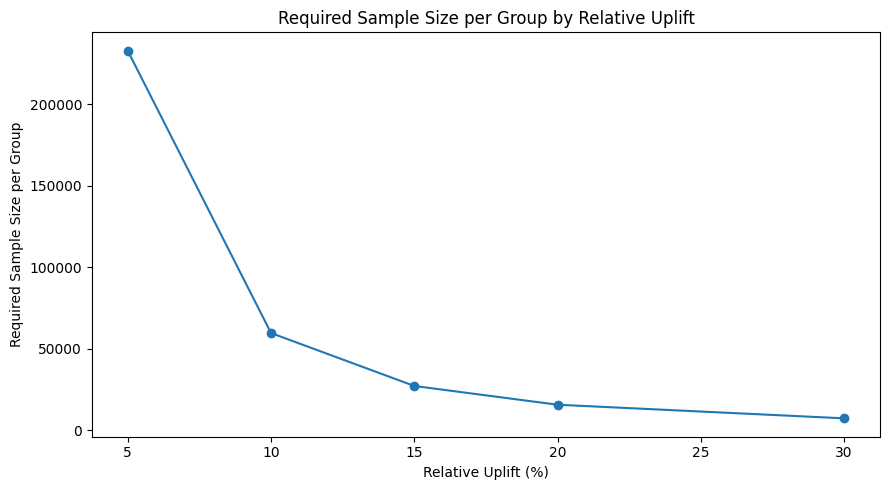

In [8]:
# ============================================================
# 7. Sample Size Scenario Chart
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(
    sample_size_scenarios["relative_uplift_pct"],
    sample_size_scenarios["required_sample_size_per_group"],
    marker="o",
)
plt.title("Required Sample Size per Group by Relative Uplift")
plt.xlabel("Relative Uplift (%)")
plt.ylabel("Required Sample Size per Group")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

save_chart("04_required_sample_size_by_uplift.png")
plt.show()

## 5. 가상의 A/B Test 결과 생성 및 검정

실제 실험 group 정보가 없기 때문에,
baseline과 목표 treatment rate를 기준으로 가상의 실험 결과를 구성한다.

대표 시나리오는 다음과 같이 설정한다.

- Baseline: 현재 `View → Add to Cart` 전환율
- Treatment: baseline 대비 +10% relative uplift
- 표본 수: sample size 계산 결과를 충족하는 값
- 검정: two-proportion z-test

In [9]:
# ============================================================
# 8. Synthetic A/B Test Result: Representative Scenario
# ============================================================

selected_relative_uplift = 0.10
selected_treatment_rate = baseline_view_to_cart * (1 + selected_relative_uplift)

selected_n_per_group = int(
    sample_size_scenarios
    .loc[sample_size_scenarios["relative_uplift"] == selected_relative_uplift, "required_sample_size_per_group"]
    .iloc[0]
)

# 기대값 기준 성공 수
control_success = int(round(selected_n_per_group * baseline_view_to_cart))
treatment_success = int(round(selected_n_per_group * selected_treatment_rate))

representative_test_result = pd.DataFrame([
    two_proportion_test(
        control_success=control_success,
        control_total=selected_n_per_group,
        treatment_success=treatment_success,
        treatment_total=selected_n_per_group,
    )
])

representative_test_result.insert(0, "scenario", "Expected result under +10% relative uplift")

display(representative_test_result)
save_table(representative_test_result, "04_representative_ab_test_result.csv")

,scenario,control_success,control_total,control_rate,treatment_success,treatment_total,treatment_rate,absolute_lift,relative_lift,z_stat,p_value,ci_low_absolute_lift,ci_high_absolute_lift,is_significant_0_05
0,Expected result under +10% relative uplift,1601,59592,0.026866,1761,59592,0.029551,0.002685,0.099938,-2.799204,0.005123,0.000805,0.004565,True


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_representative_ab_test_result.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_representative_ab_test_result.csv')

## 6. Monte Carlo Simulation

실제 실험 결과는 확률적으로 변동한다.

같은 baseline과 treatment rate, 같은 표본 수를 사용하더라도
매번 같은 성공 수가 나오지 않는다.

따라서 Monte Carlo Simulation을 통해 다음을 확인한다.

- p-value 분포
- 유의하게 탐지될 확률
- 추정 uplift의 변동성
- confidence interval의 범위

In [10]:
# ============================================================
# 9. Monte Carlo Simulation
# ============================================================

n_simulations = 1000

simulation_results = simulate_ab_test(
    baseline_rate=baseline_view_to_cart,
    treatment_rate=selected_treatment_rate,
    n_per_group=selected_n_per_group,
    n_simulations=n_simulations,
    random_state=42,
)

simulation_summary = pd.DataFrame([
    {
        "scenario": "+10% relative uplift",
        "n_simulations": n_simulations,
        "n_per_group": selected_n_per_group,
        "baseline_rate": baseline_view_to_cart,
        "treatment_rate": selected_treatment_rate,
        "mean_control_rate": simulation_results["control_rate"].mean(),
        "mean_treatment_rate": simulation_results["treatment_rate"].mean(),
        "mean_absolute_lift": simulation_results["absolute_lift"].mean(),
        "mean_relative_lift": simulation_results["relative_lift"].mean(),
        "significance_detection_rate": simulation_results["is_significant_0_05"].mean(),
        "median_p_value": simulation_results["p_value"].median(),
        "p_value_05_quantile": simulation_results["p_value"].quantile(0.05),
        "p_value_95_quantile": simulation_results["p_value"].quantile(0.95),
    }
])

display(simulation_summary)
display(simulation_results.head())

save_table(simulation_summary, "04_monte_carlo_simulation_summary.csv")
save_table(simulation_results, "04_monte_carlo_simulation_results.csv")

,scenario,n_simulations,n_per_group,baseline_rate,treatment_rate,mean_control_rate,mean_treatment_rate,mean_absolute_lift,mean_relative_lift,significance_detection_rate,median_p_value,p_value_05_quantile,p_value_95_quantile
0,+10% relative uplift,1000,59592,0.026864,0.029551,0.026864,0.029582,0.002717,0.101782,0.806000,0.004242,0.000010,0.208995


,control_success,control_total,control_rate,treatment_success,treatment_total,treatment_rate,absolute_lift,relative_lift,z_stat,p_value,ci_low_absolute_lift,ci_high_absolute_lift,is_significant_0_05,simulation_id
0,1612,59592,0.027051,1688,59592,0.028326,0.001275,0.047146,-1.341695,0.179695,-0.000588,0.003138,False,1
1,1577,59592,0.026463,1724,59592,0.028930,0.002467,0.093215,-2.594739,0.009466,0.000604,0.004330,True,2
2,1604,59592,0.026916,1793,59592,0.030088,0.003172,0.117830,-3.289979,0.001002,0.001282,0.005061,True,3
3,1657,59592,0.027806,1748,59592,0.029333,0.001527,0.054919,-1.582257,0.113591,-0.000365,0.003419,False,4
4,1551,59592,0.026027,1812,59592,0.030407,0.004380,0.168279,-4.565543,0.000005,0.002500,0.006260,True,5


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_monte_carlo_simulation_summary.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_monte_carlo_simulation_results.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_monte_carlo_simulation_results.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\04_monte_carlo_p_value_distribution.png


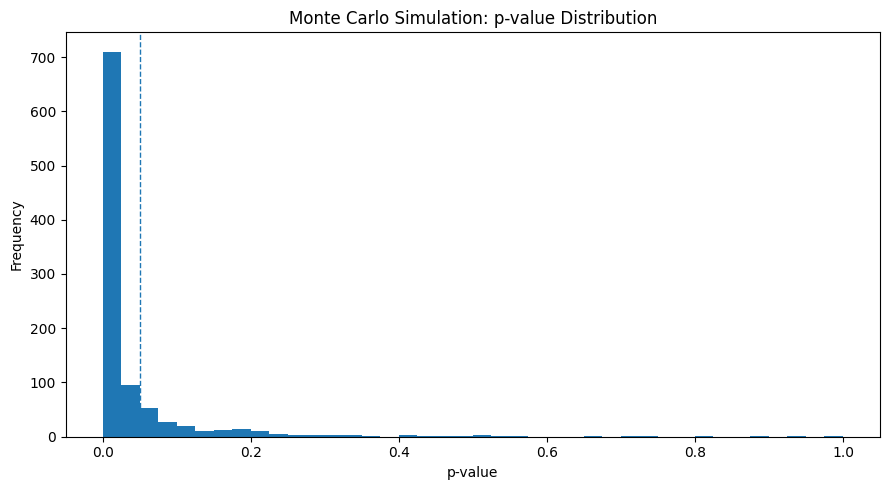

In [11]:
# ============================================================
# 10. Monte Carlo p-value Distribution
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(simulation_results["p_value"], bins=40)
plt.axvline(0.05, linestyle="--", linewidth=1)
plt.title("Monte Carlo Simulation: p-value Distribution")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.tight_layout()

save_chart("04_monte_carlo_p_value_distribution.png")
plt.show()

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\04_monte_carlo_absolute_lift_distribution.png


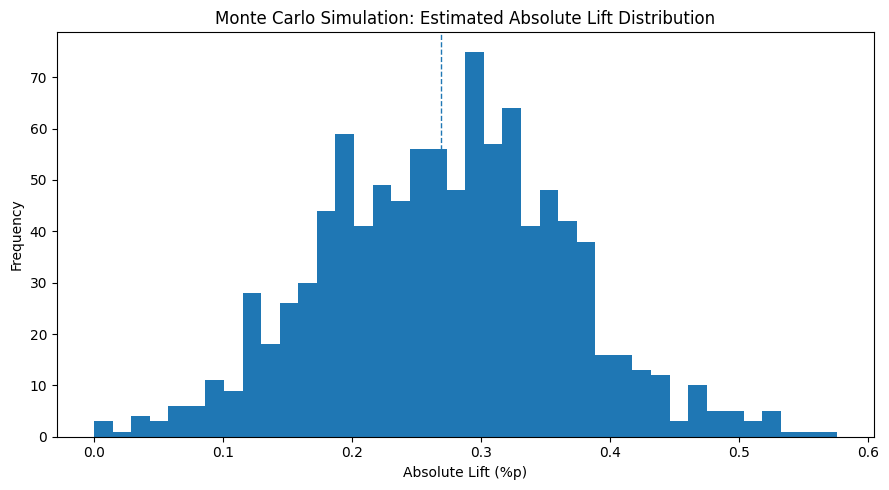

In [12]:
# ============================================================
# 11. Monte Carlo Estimated Lift Distribution
# ============================================================

plt.figure(figsize=(9, 5))
plt.hist(simulation_results["absolute_lift"] * 100, bins=40)
plt.axvline((selected_treatment_rate - baseline_view_to_cart) * 100, linestyle="--", linewidth=1)
plt.title("Monte Carlo Simulation: Estimated Absolute Lift Distribution")
plt.xlabel("Absolute Lift (%p)")
plt.ylabel("Frequency")
plt.tight_layout()

save_chart("04_monte_carlo_absolute_lift_distribution.png")
plt.show()

## 7. Business Impact Simulation

통계적으로 유의한 실험 결과라 하더라도,
비즈니스 impact가 작다면 실행 우선순위는 낮을 수 있다.

따라서 target exposure 규모별로 예상 추가 전환 수를 계산한다.

여기서는 평균 주문 금액을 알 수 없으므로 기본적으로 추가 장바구니 수를 계산한다.
필요하면 `avg_order_value`를 입력해 예상 추가 매출도 계산할 수 있다.

In [13]:
# ============================================================
# 12. Business Impact by Exposure Scenario
# ============================================================

target_exposure_scenarios = [10_000, 50_000, 100_000, 300_000, 500_000, 1_000_000]

impact_rows = []

for relative_uplift in relative_uplift_scenarios:
    treatment_rate = baseline_view_to_cart * (1 + relative_uplift)

    for target_exposures in target_exposure_scenarios:
        impact = estimate_incremental_impact(
            baseline_rate=baseline_view_to_cart,
            treatment_rate=treatment_rate,
            target_exposures=target_exposures,
            avg_order_value=None,
        )

        impact["relative_uplift"] = relative_uplift
        impact["relative_uplift_pct"] = relative_uplift * 100
        impact_rows.append(impact)

business_impact_scenarios = pd.DataFrame(impact_rows)

display(business_impact_scenarios.head(20))
save_table(business_impact_scenarios, "04_business_impact_scenarios.csv")

,target_exposures,baseline_rate,treatment_rate,absolute_lift,relative_lift,expected_baseline_conversions,expected_treatment_conversions,expected_incremental_conversions,relative_uplift,relative_uplift_pct
0,10000,0.026864,0.028207,0.001343,0.050000,268.640964,282.073012,13.432048,0.050000,5.000000
1,50000,0.026864,0.028207,0.001343,0.050000,"1,343.204819","1,410.365060",67.160241,0.050000,5.000000
2,100000,0.026864,0.028207,0.001343,0.050000,"2,686.409639","2,820.730121",134.320482,0.050000,5.000000
3,300000,0.026864,0.028207,0.001343,0.050000,"8,059.228916","8,462.190362",402.961446,0.050000,5.000000
4,500000,0.026864,0.028207,0.001343,0.050000,"13,432.048193","14,103.650603",671.602410,0.050000,5.000000
5,1000000,0.026864,0.028207,0.001343,0.050000,"26,864.096387","28,207.301206","1,343.204819",0.050000,5.000000
6,10000,0.026864,0.029551,0.002686,0.100000,268.640964,295.505060,26.864096,0.100000,10.000000
7,50000,0.026864,0.029551,0.002686,0.100000,"1,343.204819","1,477.525301",134.320482,0.100000,10.000000
8,100000,0.026864,0.029551,0.002686,0.100000,"2,686.409639","2,955.050603",268.640964,0.100000,10.000000
9,300000,0.026864,0.029551,0.002686,0.100000,"8,059.228916","8,865.151808",805.922892,0.100000,10.000000


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_business_impact_scenarios.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_business_impact_scenarios.csv')

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\04_expected_incremental_cart_users_per_100k.png


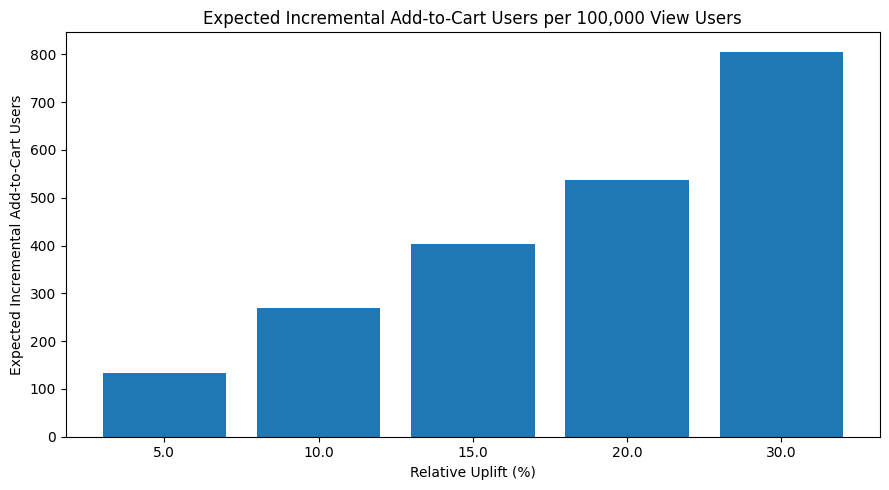

In [14]:
# ============================================================
# 13. Business Impact Chart
# ============================================================

plot_impact = business_impact_scenarios.loc[
    business_impact_scenarios["target_exposures"] == 100_000
].copy()

plt.figure(figsize=(9, 5))
plt.bar(
    plot_impact["relative_uplift_pct"].astype(str),
    plot_impact["expected_incremental_conversions"],
)
plt.title("Expected Incremental Add-to-Cart Users per 100,000 View Users")
plt.xlabel("Relative Uplift (%)")
plt.ylabel("Expected Incremental Add-to-Cart Users")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

save_chart("04_expected_incremental_cart_users_per_100k.png")
plt.show()

## 8. Category-Level Experiment Candidate Simulation

03번 노트북에서 추출한 카테고리 성과를 활용해
어떤 카테고리를 A/B Test 대상으로 삼을지 검토한다.

특히 중요한 후보는 다음이다.

- 조회는 많지만 전환율이 낮은 Optimization Category
- 조회는 적지만 전환율이 높은 Expansion Category

여기서는 고트래픽 저전환 카테고리에서 `View → Add to Cart` 개선 실험을 수행한다고 가정한다.

In [15]:
# ============================================================
# 14. Category-Level Candidate Simulation
# ============================================================

if category_performance is not None:
    min_view_users_category = 500

    eligible_categories = category_performance.loc[
        category_performance["view_users"] >= min_view_users_category
    ].copy()

    traffic_cutoff = eligible_categories["view_users"].median()
    conversion_cutoff = eligible_categories["view_to_purchase_rate"].median()

    eligible_categories["traffic_level"] = np.where(
        eligible_categories["view_users"] >= traffic_cutoff,
        "High traffic",
        "Low traffic",
    )

    eligible_categories["purchase_conversion_level"] = np.where(
        eligible_categories["view_to_purchase_rate"] >= conversion_cutoff,
        "High purchase conversion",
        "Low purchase conversion",
    )

    optimization_categories = eligible_categories.loc[
        (eligible_categories["traffic_level"] == "High traffic")
        & (eligible_categories["purchase_conversion_level"] == "Low purchase conversion")
    ].copy()

    optimization_categories = optimization_categories.sort_values(
        ["view_users", "view_to_purchase_rate"],
        ascending=[False, True],
    )

    candidate_categories = optimization_categories.head(10).copy()

    category_simulation_rows = []

    for _, row in candidate_categories.iterrows():
        baseline_rate = row["view_to_cart_rate"]

        # 카테고리별 view_to_cart_rate가 0이거나 NaN이면 전체 baseline으로 대체
        if pd.isna(baseline_rate) or baseline_rate <= 0:
            baseline_rate = baseline_view_to_cart

        for relative_uplift in [0.05, 0.10, 0.20]:
            treatment_rate = baseline_rate * (1 + relative_uplift)

            try:
                required_n = required_sample_size_per_group(
                    baseline_rate=baseline_rate,
                    treatment_rate=treatment_rate,
                    alpha=0.05,
                    power=0.80,
                )
            except Exception:
                required_n = np.nan

            available_views = int(row["view_users"])
            expected_incremental_cart_users = available_views * (treatment_rate - baseline_rate)

            category_simulation_rows.append({
                "categoryid": int(row["categoryid"]),
                "available_view_users": available_views,
                "baseline_view_to_cart_rate": baseline_rate,
                "baseline_view_to_cart_rate_pct": baseline_rate * 100,
                "relative_uplift": relative_uplift,
                "relative_uplift_pct": relative_uplift * 100,
                "treatment_rate": treatment_rate,
                "treatment_rate_pct": treatment_rate * 100,
                "absolute_lift_pct_point": (treatment_rate - baseline_rate) * 100,
                "required_sample_size_per_group": required_n,
                "required_total_sample_size": required_n * 2 if not pd.isna(required_n) else np.nan,
                "expected_incremental_cart_users_with_available_views": expected_incremental_cart_users,
                "is_current_sample_sufficient_for_one_group": available_views >= required_n if not pd.isna(required_n) else False,
            })

    category_abtest_simulation = pd.DataFrame(category_simulation_rows)

    display(candidate_categories)
    display(category_abtest_simulation)

    save_table(candidate_categories, "04_category_abtest_candidate_categories.csv")
    save_table(category_abtest_simulation, "04_category_abtest_simulation.csv")

else:
    category_abtest_simulation = pd.DataFrame()
    print("category_performance is not available.")

category_performance is not available.


In [16]:
# ============================================================
# 15. Category Candidate Impact Chart
# ============================================================

if not category_abtest_simulation.empty:
    plot_df = category_abtest_simulation.loc[
        category_abtest_simulation["relative_uplift"] == 0.10
    ].sort_values("expected_incremental_cart_users_with_available_views", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(
        plot_df["categoryid"].astype(str),
        plot_df["expected_incremental_cart_users_with_available_views"],
    )
    plt.title("Expected Incremental Cart Users by Candidate Category (+10% Uplift)")
    plt.xlabel("Expected Incremental Cart Users")
    plt.ylabel("Category ID")
    plt.tight_layout()

    save_chart("04_candidate_category_incremental_cart_users.png")
    plt.show()
else:
    print("No category simulation result to plot.")

No category simulation result to plot.


## 9. 실험 운영 관점의 의사결정 표

실무 A/B Test는 통계적으로만 판단하지 않는다.

다음 기준을 함께 검토해야 한다.

- 통계적 검정 가능성
- 기대 impact
- 구현 난이도
- 실험 리스크
- downstream metric 악화 가능성
- 충분한 표본 확보 가능성

In [17]:
# ============================================================
# 16. Experiment Decision Framework
# ============================================================

experiment_decision_framework = pd.DataFrame([
    {
        "decision_area": "Primary metric",
        "recommended_decision": "Use View → Add to Cart conversion rate.",
        "reason": "The largest funnel bottleneck occurs before cart entry.",
    },
    {
        "decision_area": "Guardrail metric",
        "recommended_decision": "Monitor View → Purchase conversion rate.",
        "reason": "Cart growth without purchase growth may indicate low-quality conversion.",
    },
    {
        "decision_area": "Experiment target",
        "recommended_decision": "Prioritize high-traffic low-conversion categories/items.",
        "reason": "These areas already have traffic and can generate impact without additional acquisition cost.",
    },
    {
        "decision_area": "Minimum detectable effect",
        "recommended_decision": "Start with +10% or +15% relative uplift scenarios.",
        "reason": "Very small uplifts require larger sample sizes and longer experiment duration.",
    },
    {
        "decision_area": "Rollout rule",
        "recommended_decision": "Ship only if primary metric improves significantly and guardrail metric does not deteriorate.",
        "reason": "Prevents optimizing shallow cart behavior at the expense of actual purchase conversion.",
    },
])

display(experiment_decision_framework)
save_table(experiment_decision_framework, "04_experiment_decision_framework.csv")

,decision_area,recommended_decision,reason
0,Primary metric,Use View → Add to Cart conversion rate.,The largest funnel bottleneck occurs before ca...
1,Guardrail metric,Monitor View → Purchase conversion rate.,Cart growth without purchase growth may indica...
2,Experiment target,Prioritize high-traffic low-conversion categor...,These areas already have traffic and can gener...
3,Minimum detectable effect,Start with +10% or +15% relative uplift scenar...,Very small uplifts require larger sample sizes...
4,Rollout rule,Ship only if primary metric improves significa...,Prevents optimizing shallow cart behavior at t...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_experiment_decision_framework.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_experiment_decision_framework.csv')

## 10. Final Business Interpretation

이 노트북의 결론은 다음과 같다.

1. 이 프로젝트의 primary A/B Test metric은 `View → Add to Cart`가 적절하다.
2. 전체 baseline conversion rate는 낮기 때문에 작은 uplift를 검출하려면 큰 표본이 필요하다.
3. 실험 대상은 전체 플랫폼보다 고트래픽 저전환 상품/카테고리로 좁히는 것이 효율적이다.
4. Treatment는 CTA, 혜택 메시지, 리뷰/신뢰 요소, 추천 영역, 장바구니 진입 UX 개선으로 설계할 수 있다.
5. 최종 의사결정은 primary metric뿐 아니라 `View → Purchase` guardrail metric과 함께 판단해야 한다.

In [18]:
# ============================================================
# 17. Final A/B Test Insight Summary
# ============================================================

best_sample_size_scenario = sample_size_scenarios.loc[
    sample_size_scenarios["relative_uplift"] == selected_relative_uplift
].iloc[0]

final_abtest_insight_summary = pd.DataFrame([
    {
        "insight_area": "Primary metric",
        "finding": f"View → Add to Cart baseline conversion rate is {baseline_view_to_cart * 100:.2f}%.",
        "business_meaning": "The biggest opportunity is before cart entry, not only after cart or checkout.",
    },
    {
        "insight_area": "Sample size",
        "finding": (
            f"To detect a +{selected_relative_uplift * 100:.0f}% relative uplift, "
            f"approximately {int(best_sample_size_scenario['required_sample_size_per_group']):,} users per group are required."
        ),
        "business_meaning": "Small conversion improvements require enough traffic and experiment duration.",
    },
    {
        "insight_area": "Expected impact",
        "finding": (
            f"With 100,000 view users, a +{selected_relative_uplift * 100:.0f}% relative uplift would generate "
            f"about {100000 * (selected_treatment_rate - baseline_view_to_cart):,.0f} additional add-to-cart users."
        ),
        "business_meaning": "Even small percentage-point improvements can matter at scale.",
    },
    {
        "insight_area": "Experiment target",
        "finding": "High-traffic low-conversion categories/items should be prioritized.",
        "business_meaning": "These targets combine visibility with clear optimization potential.",
    },
    {
        "insight_area": "Decision rule",
        "finding": "Ship treatment only if the primary metric improves and purchase conversion does not deteriorate.",
        "business_meaning": "The experiment should optimize business-quality conversion, not only shallow engagement.",
    },
])

display(final_abtest_insight_summary)
save_table(final_abtest_insight_summary, "04_final_abtest_insight_summary.csv")

,insight_area,finding,business_meaning
0,Primary metric,View → Add to Cart baseline conversion rate is...,"The biggest opportunity is before cart entry, ..."
1,Sample size,"To detect a +10% relative uplift, approximatel...",Small conversion improvements require enough t...
2,Expected impact,"With 100,000 view users, a +10% relative uplif...",Even small percentage-point improvements can m...
3,Experiment target,High-traffic low-conversion categories/items s...,These targets combine visibility with clear op...
4,Decision rule,Ship treatment only if the primary metric impr...,The experiment should optimize business-qualit...


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\04_final_abtest_insight_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/04_final_abtest_insight_summary.csv')

In [19]:
# ============================================================
# 18. Save Streamlit-Ready Summary Tables
# ============================================================

streamlit_tables = {
    "abtest_baseline_summary.parquet": baseline_summary,
    "abtest_sample_size_scenarios.parquet": sample_size_scenarios,
    "abtest_business_impact_scenarios.parquet": business_impact_scenarios,
    "abtest_final_insight_summary.parquet": final_abtest_insight_summary,
}

if not category_abtest_simulation.empty:
    streamlit_tables["abtest_category_simulation.parquet"] = category_abtest_simulation

for filename, df in streamlit_tables.items():
    save_path = PROCESSED_DIR / filename
    try:
        df.to_parquet(save_path, index=False)
        print(f"saved: {save_path}")
    except Exception as e:
        print(f"parquet save failed for {filename}: {e}")

print("04_ab_test_design_simulation completed.")
print("Next notebook: 05_business_recommendation.ipynb")

parquet save failed for abtest_baseline_summary.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
parquet save failed for abtest_sample_size_scenarios.parquet: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or con